# 01 — Data, preprocessing, and the clip cache

**Demonstrates:** the five candidate sources (four fetched, one skipped), the manifest that
records every clip's `group_id` and `split`, why splits are grouped by source video rather than
by clip row, the leakage assertion, and the Phase 2 clip cache that `scripts/build_cache.py`
produced from it.

**Maps to:** report §4.1 (data sources) and §4.2 (preprocessing), `docs/BUILD_PLAN.md` Phases 1-2,
`docs/decisions/ADR-002-dataset-splits.md`, `docs/DATASETS.md`.


In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd  # noqa: E402

from safestreets.config import load_config  # noqa: E402

pd.set_option("display.max_columns", None)
cfg = load_config(REPO_ROOT / "configs" / "data.yaml")
cfg


DataConfig(data_root='data', manifests_dir='data/manifests', cache_dir='data/cache', raw_dir='data/raw', seed=1265)

## The manifest

`safestreets/data/manifest.py:build_manifest` scanned each dataset's raw directory once and wrote one row per clip. `group_id` is the grouping key ADR-002 derives per dataset (source-video stem, content near-duplicate cluster, or event id); `split` is assigned from `hash(salt:dataset:group_id) % 100`, never from a per-clip random split.

In [2]:
manifest = pd.read_parquet(REPO_ROOT / "data" / "manifests" / "clips.parquet")
print(f"{len(manifest)} clips total, {manifest['group_id'].nunique()} distinct groups")
manifest.head(3)


4336 clips total, 3873 distinct groups


,clip_id,dataset,path,label,split,group_id,n_frames,fps,width,height,duration_s,source_video,category
0,rwf2000_Fight_-1l5631l3fg_0,rwf2000,data/raw/rwf2000/train/Fight/-1l5631l3fg_0.avi,1,train,-1l5631l3fg_0,50,10.0,640,360,5.0,-1l5631l3fg_0,Fight
1,rwf2000_Fight_-1l5631l3fg_1,rwf2000,data/raw/rwf2000/train/Fight/-1l5631l3fg_1.avi,1,train,-1l5631l3fg_1,50,10.0,640,360,5.0,-1l5631l3fg_1,Fight
2,rwf2000_Fight_-1l5631l3fg_2,rwf2000,data/raw/rwf2000/train/Fight/-1l5631l3fg_2.avi,1,train,-1l5631l3fg_2,50,10.0,640,360,5.0,-1l5631l3fg_2,Fight


In [3]:
counts = manifest.groupby(["dataset", "split"]).size().unstack(fill_value=0)
counts = counts[["train", "val", "test"]]
pct = counts.div(counts.sum(axis=1), axis=0) * 100
display(counts)
display(pct.round(1).astype(str) + "%")


split,train,val,test
dataset,,,
airtlab,242,60,48
rlvs,1404,274,273
rwf2000,1600,400,0
ucfcrime,24,6,5


split,train,val,test
dataset,,,
airtlab,69.1%,17.1%,13.7%
rlvs,72.0%,14.0%,14.0%
rwf2000,80.0%,20.0%,0.0%
ucfcrime,68.6%,17.1%,14.3%


RWF-2000 contributes 0 test rows by design (ADR-002: its official train/val split is used
verbatim rather than re-bucketed, since the authors already kept each source video's segments on
one side). Held-out test coverage for that style of footage comes from the pooled
RLVS + AIRTLab + UCF-Crime test split instead, scored in notebook 04.

## Why splits are grouped, not clip-random

`train_test_split` on clip rows would let sibling clips cut from the same source video (or, for AIRTLab, the same event filmed from two cameras) land on both sides of a split, inflating every metric with near-duplicate leakage (CLAUDE.md's non-negotiable). The assertion below is the actual check Phase 1's exit gate ran: for every dataset, the set of `group_id`s in train, val, and test are pairwise disjoint.

In [4]:
leakage_free = True
for dataset, group in manifest.groupby("dataset"):
    by_split = {s: set(g["group_id"]) for s, g in group.groupby("split")}
    splits_present = list(by_split)
    overlaps = {}
    for i, a in enumerate(splits_present):
        for b in splits_present[i + 1:]:
            shared = by_split[a] & by_split[b]
            if shared:
                overlaps[(a, b)] = shared
    status = "OK, no overlap" if not overlaps else f"LEAK: {overlaps}"
    if overlaps:
        leakage_free = False
    print(f"{dataset:10s} groups={sum(len(v) for v in by_split.values()):5d}  {status}")

assert leakage_free, "group_id leakage detected across a split boundary"
print("\nleakage assertion passed: no dataset shares a group_id across train/val/test")


airtlab    groups=  175  OK, no overlap
rlvs       groups= 1920  OK, no overlap
rwf2000    groups= 1743  OK, no overlap
ucfcrime   groups=   35  OK, no overlap

leakage assertion passed: no dataset shares a group_id across train/val/test


## A visual sanity check: the clip cache

`scripts/make_contact_sheet.py` tiled all 16 sampled, letterboxed frames of four random cached clips, one per row, so orientation and colour can be eyeballed directly rather than trusted blindly.

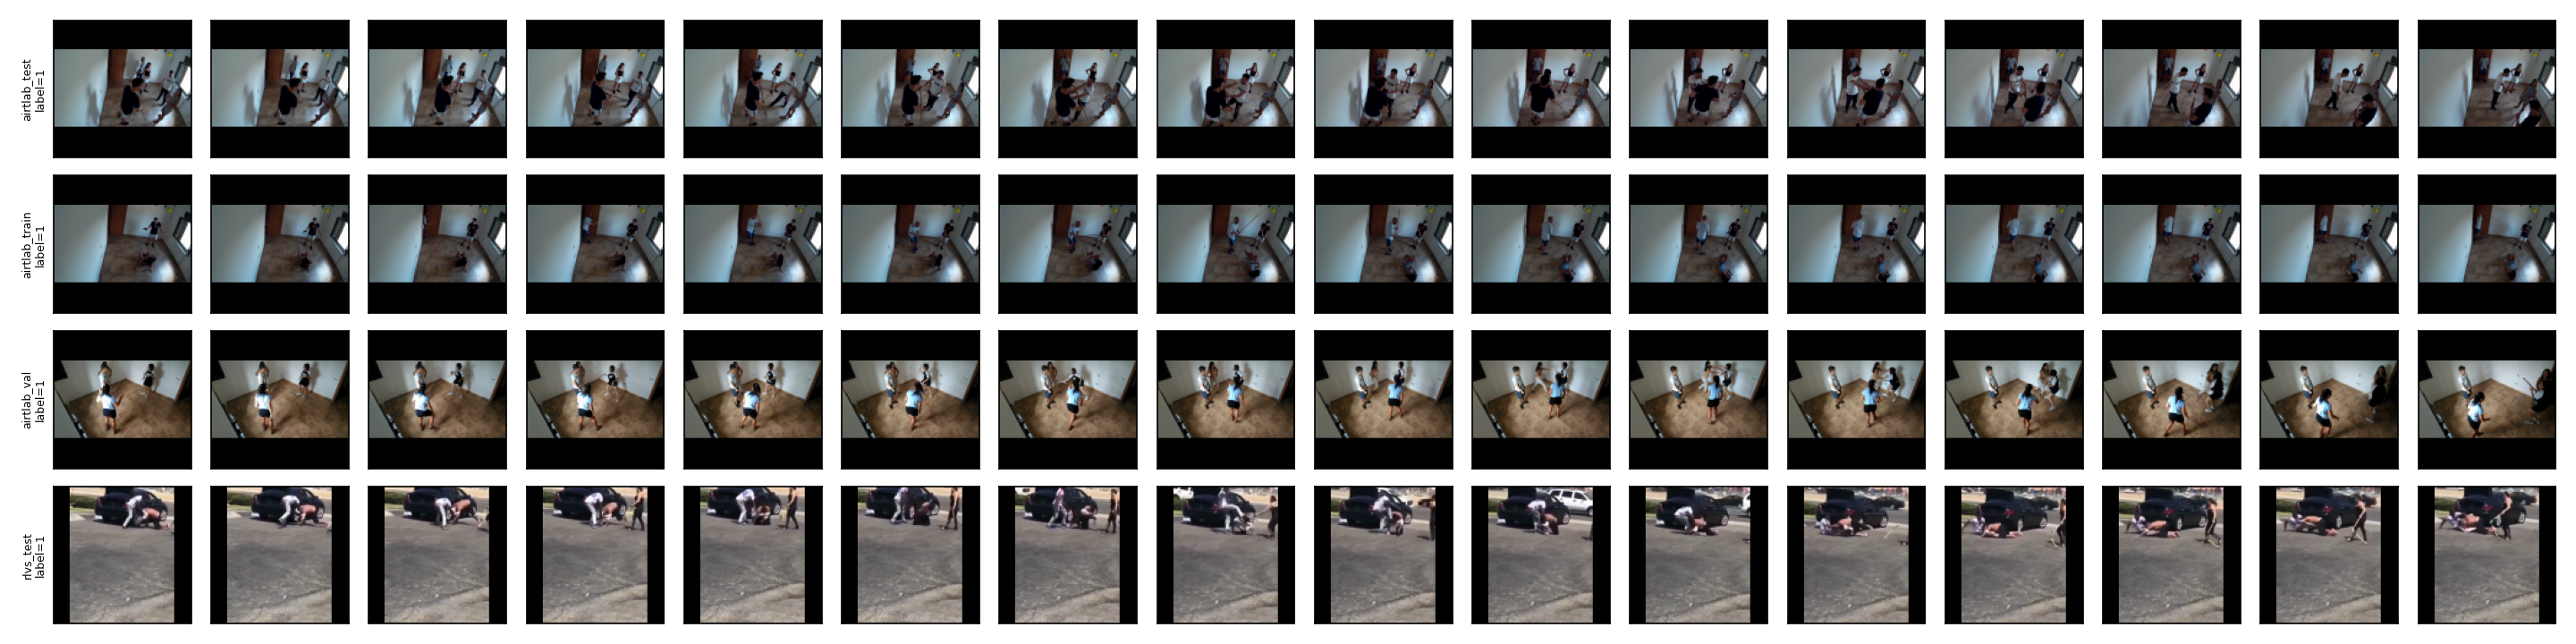

In [5]:
from IPython.display import Image

Image(filename=str(REPO_ROOT / "artifacts" / "figures" / "sample_clips.png"))


## Cache validity

`CacheIndex` (used by the live `tf.data` pipeline in notebook 02) refuses to open a cache file whose stored `(n_frames, height, width)` disagrees with the active `configs/data.yaml` pipeline block (`StaleCacheError`). Building the index for the real train cache below is itself the validity check.

In [6]:
import json

from safestreets.data.dataset import CacheIndex, load_pipeline_config

pipeline_cfg = load_pipeline_config(REPO_ROOT / "configs" / "data.yaml")
index = CacheIndex(cfg.cache_dir, "train", pipeline_cfg)
print(f"train cache: {len(index)} clips across {len(index.paths)} files, shape check passed")

cache_report = json.loads((Path(cfg.cache_dir) / "cache_report.json").read_text())
cache_report


/opt/anaconda3/envs/safestreets/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train cache: 3268 clips across 4 files, shape check passed


{'airtlab': {'test': {'bytes': 28909056,
   'n_manifest': 48,
   'n_skipped': 0,
   'n_written': 48,
   'skipped': [],
   'wall_s': 206.0657820701599},
  'train': {'bytes': 145730468,
   'n_manifest': 242,
   'n_skipped': 0,
   'n_written': 242,
   'skipped': [],
   'wall_s': 1100.4589779376984},
  'val': {'bytes': 36134616,
   'n_manifest': 60,
   'n_skipped': 0,
   'n_written': 60,
   'skipped': [],
   'wall_s': 218.00008606910706}},
 'rlvs': {'test': {'bytes': 163794368,
   'n_manifest': 273,
   'n_skipped': 1,
   'n_written': 272,
   'skipped': [{'clip_id': 'rlvs_NV_357',
     'path': 'data/raw/rlvs/Real Life Violence Dataset/NonViolence/NV_357.mp4',
     'reason': 'unreadable_frame'}],
   'wall_s': 111.79491901397705},
  'train': {'bytes': 844258612,
   'n_manifest': 1404,
   'n_skipped': 2,
   'n_written': 1402,
   'skipped': [{'clip_id': 'rlvs_V_8',
     'path': 'data/raw/rlvs/Real Life Violence Dataset/Violence/V_8.mp4',
     'reason': 'unreadable_frame'},
    {'clip_id': 'rlvs

## Limitations

- **XD-Violence was never fetched.** Its only real distribution (OneDrive) turned out to be
  38.3 GB, far over the ~44 GB disk budget; see `docs/DATASETS.md` for the full account. It fed
  only a supplementary cross-dataset/frame-level evaluation, not the primary training pool, so
  skipping it does not block any other sprint.
- **RLVS's `group_id` is a content near-duplicate heuristic** (average-hash of the middle frame
  plus duration bucket plus label), not ground truth parsed from a filename, because this
  mirror's filenames (`V_<n>.mp4`) carry no source-video id. It is a real, checkable proxy, but
  it will under-cluster near-duplicates that differ at the one sampled frame.
- **UCF-Crime here is an intentionally small subset** (35 clips total), feeding cross-dataset
  evaluation rather than training; its test split (5 clips) is too small for a stable metric on
  its own, let alone a frame-level one.
